In [60]:
#======================#
#   Import Libraries   #
#======================#

import ROOT
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
import pandas as pd
import re
from tqdm import tqdm

ROI_min = 5000
ROI_max = 6800

In [61]:
#==========================#
#   Recover the Runs IDs   #
#==========================#

df = pd.read_excel("/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx", sheet_name="Beamtime 5")

df = df[df['Run Type'] == "Scan_pg"]

targets = df['Target'].dropna().astype(str).unique()
print(targets)

RUNS = []
for target in targets:
    runs_temp = df[df['Target'] == target]['Run Number'].tolist()
    RUNS.append(runs_temp)

print(f"{len(targets)} target types found for scan_pg")

['IMP_LTA#3' 'IMP_LTA#4']
2 target types found for scan_pg


In [62]:
#=============================#
#   Recover the RUNS energy   #
#=============================#

df = pd.read_excel("/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx", sheet_name="Beamtime 5")

E = []
    
for target in targets:
    df_temp = df[(df["Target"] == target) & (df["Run Type"] == "Scan_pg")]
    E.append(df_temp['Energy'].tolist())

print(E)

[[250.1, 248.3, 246.3, 244.3, 242.4, 240.4, 239.4, 238.4, 237.4, 235.4, 230.4, 228.5, 226.6, 256.4, 260.3, 232.6, 264.8, 269.8, 269.8], [235.6, 237.4, 237.9, 238.5, 239.0, 239.5, 240.5, 241.5, 242.5, 246.3, 248.3, 250.1, 252.1, 254.0, 256.0, 260.0, 264.0, 268.0, 235.6, 234.6, 233.6, 232.6, 231.7, 233.6, 230.4, 229.4, 228.4, 227.4, 226.4, 225.4, 224.4, 234.2, 233.2, 236.3, 231.0]]


In [63]:
#=============================================#
#   Recover the current of each RUN in RUNS   #
#=============================================#

charge = []

for target in targets:
    charge.append([])
    
    df_temp = df[(df["Target"] == target) & (df["Run Type"] == "Scan_pg")]
    runs_temp = df_temp['Run Number'].tolist()
    for run in tqdm(runs_temp, desc=f"Processing runs for target {target}"):
        try:
            time, current = np.genfromtxt(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/CURRENT/run{run}.txt", usecols=(0, 2), unpack=True)
            # print(f"Run {run}: Time and Charge data extracted successfully.")
        except Exception as e:
            print(f"Error extracting data for run {run}: {e}")
        
        # Compute the total charge by multiplying the current by the time intervals only where current>0
        time_diff = np.diff(np.insert(time, 0, 0))  # Time intervals

        current_positive = current[current > 0]
        time_diff_positive = time_diff[current > 0]

        total_charge = np.sum(current_positive * time_diff_positive)  # Total charge in uC

        charge[-1].append(total_charge)
    
print(charge)

Processing runs for target IMP_LTA#4: 100%|██████████| 35/35 [00:00<00:00, 187.50it/s]


[[np.float64(101903.597221028), np.float64(161790.7300534976), np.float64(144511.789100345), np.float64(91492.507202946), np.float64(114597.29862779101), np.float64(123830.753414298), np.float64(130987.15031705302), np.float64(101635.072589673), np.float64(61180.532226144), np.float64(69950.54627104788), np.float64(81582.85237072699), np.float64(79875.09057629202), np.float64(72922.844742438), np.float64(88453.8067059544), np.float64(88566.7808055299), np.float64(80907.643202524), np.float64(105874.050109132), np.float64(25399.022473758), np.float64(71430.62942685401)], [np.float64(116745.4528184486), np.float64(130119.28611872), np.float64(117701.846138133), np.float64(123645.931630769), np.float64(113252.45699949202), np.float64(126316.19485895999), np.float64(125134.65577384201), np.float64(125682.90764775951), np.float64(125307.790522122), np.float64(125408.0695062098), np.float64(134132.538251536), np.float64(126328.700263864), np.float64(120508.66324585717), np.float64(124417.362

In [64]:
#=====================================#
#   Recover the deadtime correction   #
#=====================================#

from yaml import scan


DT_correction = []

def event_recoverer(run, branch):
    f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run{run}.root")

    f.cd(branch)
    dir = ROOT.gDirectory

    branch_events = []

    for BGO in range(1, 7):
        BGO_name = f"BGO{BGO}"
        BGO_hist = dir.Get(BGO_name)

        counts = np.array([BGO_hist.GetBinContent(i) for i in range(1, BGO_hist.GetNbinsX()+2)])

        counts = np.sum(counts)
        branch_events.append(counts)
    
    # print(branch_events)

    branch_events = np.sum(branch_events)

    return branch_events

for target in targets:
    DT_correction.append([])
    for run in tqdm(RUNS[list(targets).index(target)], desc=f"Processing target {target}"):
        energyspectra = event_recoverer(run, "EnergySpectra")
        lost = event_recoverer(run, "LostCountRates")
        saturation = event_recoverer(run, "SaturationCountRates")
        dead = event_recoverer(run, "DeadCountRates")
        trigger = event_recoverer(run, "TriggerCountRates")
        pilup = event_recoverer(run, "PileUpCountRates")

        DT_run = 1 - (energyspectra) / (energyspectra + pilup + lost + saturation + dead + trigger)

        DT_average = np.mean(DT_run)

        DT_correction[-1].append(DT_average)

print(DT_correction)

Processing target IMP_LTA#4: 100%|██████████| 35/35 [00:01<00:00, 23.68it/s]

[[np.float64(0.0010969910753682033), np.float64(0.0014384566206611105), np.float64(0.0015716114171911988), np.float64(0.00171668372774203), np.float64(0.0020708255840174994), np.float64(0.0023688908062753367), np.float64(0.002630732564180782), np.float64(0.0029036389038189503), np.float64(0.00322912784983187), np.float64(0.004160822273094222), np.float64(0.005917370962622126), np.float64(0.00600550416726886), np.float64(0.004390822601498701), np.float64(0.001086556854190679), np.float64(0.001371071199486873), np.float64(0.005394016301763949), np.float64(0.0011006304183972526), np.float64(0.001210731581879787), np.float64(0.0010286098853615755)], [np.float64(0.004435320089148154), np.float64(0.0035764636216901735), np.float64(0.0033565428425399446), np.float64(0.0031453859543256746), np.float64(0.0030556753178687668), np.float64(0.00308468600005829), np.float64(0.0027619227475637054), np.float64(0.0024819895613888976), np.float64(0.002170963090593947), np.float64(0.0016339562941929398),

In [65]:
###########################################
# Recover the yield in the gated spectrum #
###########################################

counts_gated = []
counts_gated_error = []

for target in targets:
    counts_gated.append([])
    counts_gated_error.append([])
    
    for run in tqdm(RUNS[list(targets).index(target)], desc=f"Processing runs for target {target}"):
        f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run{run}.root")
        df = ROOT.RDataFrame("coincidenceEvents", f)

        df = df.Filter("isPulser == 0")

        gate_min, gate_max = 11500, 14500
        df_gated = df.Filter(f"energySum > {gate_min} && energySum < {gate_max} && isPulser == 0 && deltaT < 10")
        events_gated = df_gated.AsNumpy(columns=["energyBGO1", "energyBGO2", "energyBGO3", "energyBGO4", "energyBGO5", "energyBGO6"])

        gated_events = np.concatenate([events_gated["energyBGO1"], events_gated["energyBGO2"], events_gated["energyBGO3"],
                                    events_gated["energyBGO4"], events_gated["energyBGO5"], events_gated["energyBGO6"]])

        ROI_gated_energy_min, ROI_gated_energy_max = 1250, 2200
        counts = np.sum((gated_events > ROI_gated_energy_min) & (gated_events < ROI_gated_energy_max))

        tidx = list(targets).index(target)
        ridx = RUNS[tidx].index(run)
        counts = counts / (1.0 - DT_correction[tidx][ridx])  # Correct for deadtime
        
        counts_gated[-1].append(counts)
        counts_gated_error[-1].append(np.sqrt(counts))

print(counts_gated)

Processing runs for target IMP_LTA#4: 100%|██████████| 35/35 [00:23<00:00,  1.49it/s]

[[np.float64(475.5216429985138), np.float64(1087.5644142320475), np.float64(1277.0069587161508), np.float64(888.5253169533006), np.float64(1137.3552643795942), np.float64(906.1465622604768), np.float64(693.825268728295), np.float64(255.74258411660415), np.float64(20.064791777931195), np.float64(17.071029519850843), np.float64(35.208340813572335), np.float64(33.199379008989226), np.float64(13.057332430350465), np.float64(96.10442291944116), np.float64(54.07413949529904), np.float64(31.168121354682516), np.float64(52.057295843304644), np.float64(12.01454639075725), np.float64(46.04736477460201)], [np.float64(29.129197314027667), np.float64(65.23330454061214), np.float64(151.50854492204172), np.float64(360.1327565140318), np.float64(498.52332542087044), np.float64(748.3082961247836), np.float64(1132.1268468915573), np.float64(1268.1475289291031), np.float64(1180.5629586092632), np.float64(1021.6693630863991), np.float64(899.2895502454695), np.float64(633.8328205584928), np.float64(383.473

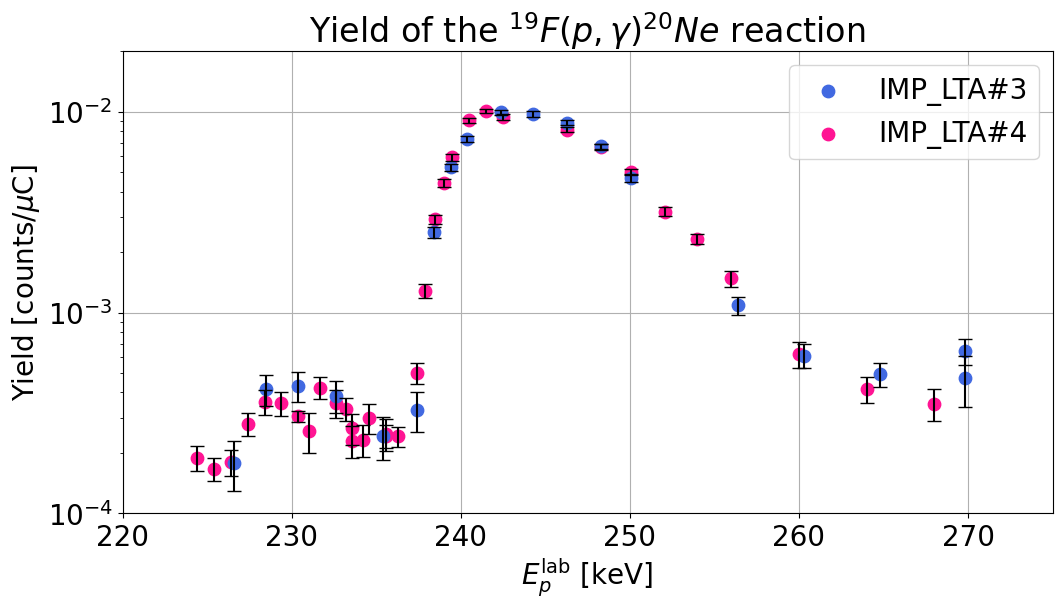

In [67]:
##################
# Plot the yield #
##################

colors = ['royalblue', 'deeppink']

Y, Y_err = [], []

for target in targets:
    idx = list(targets).index(target)

    Y.append(np.array(counts_gated[idx])/np.array(charge[idx]))
    Y_err.append(np.array(counts_gated_error[idx])/np.array(charge[idx]))


# Plotting the yield with error bars #

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.set_title(r"Yield of the ${}^{19}F(p,\gamma)^{20}Ne$ reaction")
plt.yscale('log')

for target in targets:
    idx = list(targets).index(target)

    ax.scatter(E[idx], Y[idx], color=colors[idx], s=80, label=target, zorder=3-idx)
    ax.errorbar(E[idx], Y[idx], yerr=Y_err[idx], fmt='none', ecolor="black", capsize=5, zorder=4)

ax.set_xlim(220, 275)
ax.set_ylim(1e-4, 2e-2)

ax.set_xlabel(r"$E_p^\text{lab}$ [keV]")
ax.set_ylabel(r"Yield [counts/$\mu$C]")

ax.grid()
ax.legend()

# ax_ins = ax.inset_axes([0.57, 0.57, 0.42, 0.42])
# ax_ins.set_yscale('log')
# for target in targets:
#     idx = list(targets).index(target)

#     ax_ins.scatter(E[idx], Y[idx], color=colors[idx], s=80)
#     ax_ins.errorbar(E[idx], Y[idx], yerr=Y_err[idx], fmt='none', ecolor="black", capsize=5)
# ax_ins.set_xlim(222, 237)
# ax_ins.set_ylim(8e-5, 5e-4)
# ax_ins.grid()

plt.savefig("/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/yield_pg.png", dpi=300, bbox_inches='tight')
plt.show()